<a href="https://colab.research.google.com/github/keyladiazv/StudentPerformanceFactors/blob/main/StudentPerformanceFactors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo del proyecto

Objetivo del Proyecto

El objetivo de este proyecto es analizar los factores que influyen en el rendimiento académico de los estudiantes y desarrollar un modelo predictivo capaz de estimar la puntuación obtenida en los exámenes a partir de variables académicas, personales y de comportamiento.

Para ello, se realizó un proceso de análisis exploratorio de datos (EDA), limpieza y preparación de la información, identificación de relaciones entre variables y construcción de un modelo de Machine Learning basado en Regresión Lineal. Asimismo, se evaluó el desempeño del modelo mediante métricas de error y capacidad explicativa, con el fin de comprender qué factores tienen mayor impacto en los resultados académicos y qué tan preciso puede ser el modelo para realizar predicciones.

# Importación de Librerias

In [30]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cargar los datos

In [10]:
# Download latest version
path = kagglehub.dataset_download("lainguyn123/student-performance-factors")

print("Path to dataset files:", path)

# Ver archivos dentro de la carpeta
print(os.listdir(path))

Using Colab cache for faster access to the 'student-performance-factors' dataset.
Path to dataset files: /kaggle/input/student-performance-factors
['StudentPerformanceFactors.csv']


In [16]:
# Cargar los datos
csv_file = os.path.join(path, "StudentPerformanceFactors.csv")
df = pd.read_csv(csv_file)

# Análisis Explortorio

In [15]:
# Mostras las 5 primeras filas
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [12]:
# Resumen la info del DataFrame
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [13]:
# Resumen descripción estadístico
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [17]:
# Revisar si hay valores nulos
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [18]:
# Ver si hay valores duplicados
df.duplicated().sum()

np.int64(0)

# Limpieza y Procesamiento

In [23]:
# Definimos columnas numéricas
num_features = df.select_dtypes(include=["int"]).columns
# Definimos columnas categóricas
cat_features = df.select_dtypes(include=["object"]).columns

## Categóricas en numéricas
# LabelEncoder
label_encoder = LabelEncoder()

for col in cat_features:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

## Escolar numéricas
# Normalización
minimax_scaler = MinMaxScaler(feature_range=(0, 1))

df[num_features] = minimax_scaler.fit_transform(df[num_features])

# Mostrar el DataFrame transformado
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,0.511628,0.600,0.5,0.0,0.0,0.500000,0.46,0.5,1.0,0.000,0.5,0.666667,1.0,1.0,0.500000,0.0,0.333333,0.666667,1.0,0.260870
1,0.418605,0.100,0.5,1.0,0.0,0.666667,0.18,0.5,1.0,0.250,1.0,0.666667,1.0,0.0,0.666667,0.0,0.000000,0.333333,0.0,0.130435
2,0.534884,0.950,1.0,1.0,1.0,0.500000,0.82,1.0,1.0,0.250,1.0,0.666667,1.0,0.5,0.666667,0.0,0.666667,0.666667,1.0,0.413043
3,0.651163,0.725,0.5,1.0,1.0,0.666667,0.96,1.0,1.0,0.125,1.0,0.666667,1.0,0.0,0.666667,0.0,0.333333,0.333333,1.0,0.347826
4,0.418605,0.800,1.0,1.0,1.0,0.333333,0.30,1.0,1.0,0.375,1.0,0.000000,1.0,0.5,0.666667,0.0,0.000000,0.666667,0.0,0.326087


In [25]:
# Eliminar valores nulos

# Imputar valores nulos con la media
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mean())
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mean())
df["Distance_from_Home"] = df["Distance_from_Home"].fillna(df["Distance_from_Home"].mean())

# Ingeniería de Características

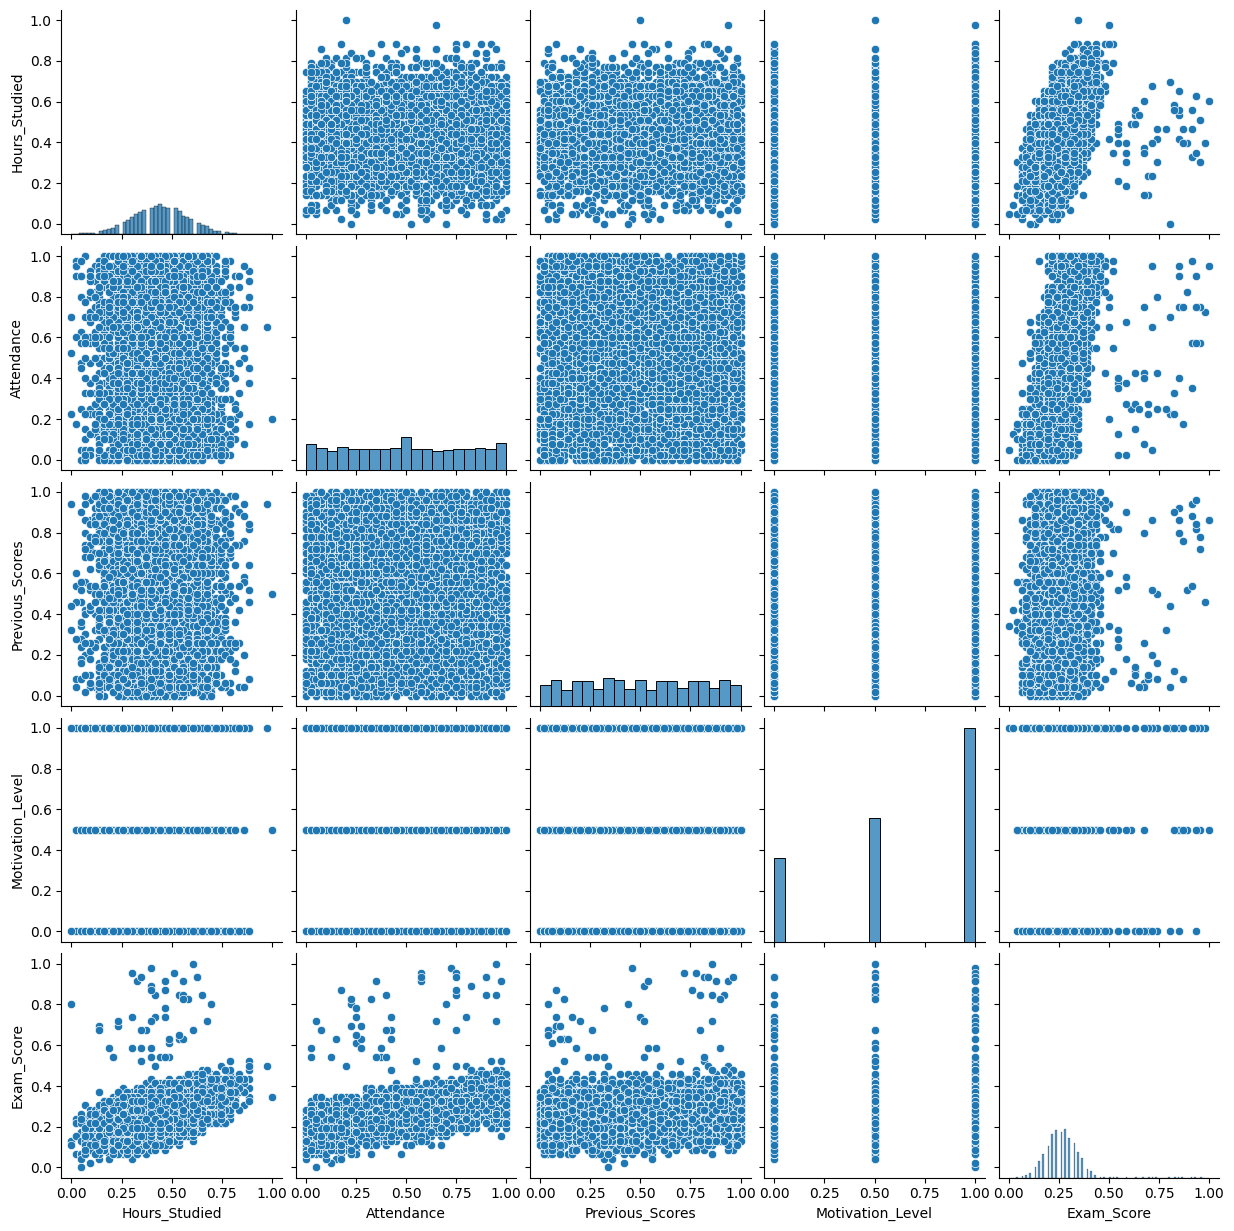

In [26]:
# Crear pairplot
sns.pairplot(df[["Hours_Studied", "Attendance", "Previous_Scores", "Motivation_Level", "Exam_Score"]])
plt.show()

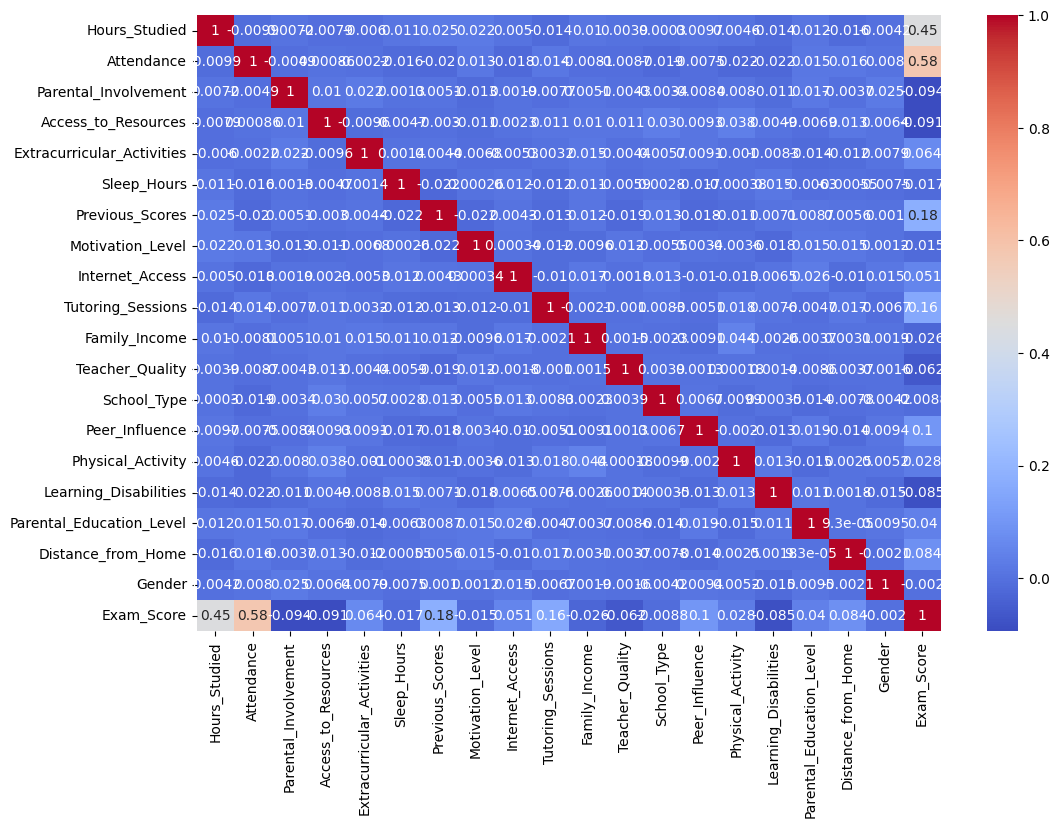

In [28]:
# Correlación entre variables
# df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [29]:
# X-Y split
x = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

# train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Entrenamiento del modelo

In [32]:
# Llamar al modelo
model_lr = LinearRegression()

In [33]:
# Entrenar el modelo
model_lr.fit(x_train, y_train)

LinearRegression()

In [34]:
# Realizar predicciones
y_pred = model_lr.predict(x_test)

# Evaluaciones

In [35]:
# Evaluar modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 0.0020800507185514934
R-squared: 0.6886194019277317


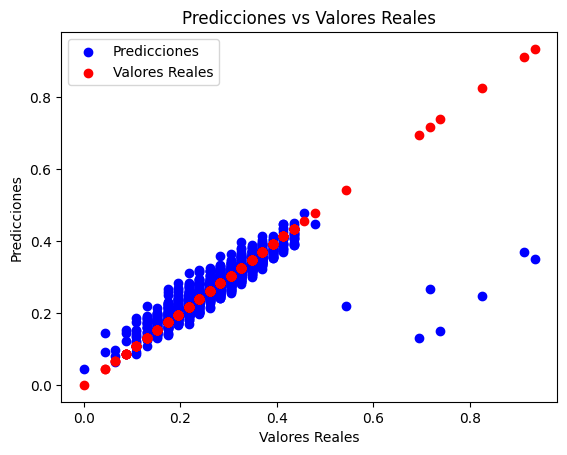

In [36]:
# Mostrar reales vs falsos
# Suponiendo que y_test son datos reales y y_pred_rf las predicciones
plt.scatter(y_test, y_pred, color="blue", label="Predicciones")
plt.scatter(y_test, y_test, color="red", label="Valores Reales")

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales")
plt.legend()
plt.show()

# Conclusiones


El análisis exploratorio permitió identificar que las variables Hours Studied y Attendance presentan la relación positiva más fuerte con la puntuación obtenida en los exámenes. Esto sugiere que los hábitos de estudio y la asistencia regular son factores clave para el rendimiento académico de los estudiantes.

Asimismo, variables como Previous Scores y Tutoring Sessions también muestran una correlación positiva con la puntuación final, aunque su impacto parece ser menor en comparación con las horas de estudio y la asistencia. Por otro lado, Motivation Level no evidencia una relación lineal significativa dentro de este conjunto de datos.

Para la fase de modelado se utilizó una Regresión Lineal, obteniendo un Mean Squared Error (MSE) de 0.00208 y un coeficiente de determinación R² de 0.6886. Esto indica que el modelo logra explicar aproximadamente el 68.86% de la variabilidad de las puntuaciones de los exámenes, alcanzando un desempeño aceptable para fines predictivos.

El análisis de las predicciones muestra que el modelo captura adecuadamente la tendencia general de los datos. Sin embargo, se observan algunas desviaciones en estudiantes con puntuaciones más elevadas, lo que sugiere la existencia de relaciones más complejas que una regresión lineal no logra modelar completamente.

Como trabajo futuro, sería recomendable evaluar modelos más avanzados como Random Forest o XGBoost para determinar si es posible mejorar la capacidad predictiva y explicar una mayor proporción de la variabilidad observada en los resultados académicos.